# LT-CCD Damage Polygon Cluster Filtering

This notebook filters LT-CCD damage polygons using area filtering and DBSCAN clustering.

## Goal
The notebook:
- loads LT-CCD damage polygons
- cleans geometries
- removes tiny polygons
- clusters polygons based on centroid proximity
- removes isolated polygons if requested
- dissolves polygons by cluster
- exports filtered outputs and cluster summary

## Input
- LT-CCD damage polygons
- AOI boundary

## Output
- Damage polygons with cluster IDs
- Filtered clustered polygons
- Dissolved damage clusters
- Cluster summary CSV

In [120]:
import os
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [121]:
# =========================
# INPUTS
# =========================
damage_polygons_path = Path("/Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Results/Lebanon_South/SLC_1/LTCCD_Results_post02032026/vectors/ltccd_damage_polygons.geojson")
roi_path = Path("/Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Row_Data/Lebanon_AOI/Lebanon_South_AOI.geojson")

# =========================
# OUTPUT DIRECTORY
# =========================
output_dir = Path("/Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Results/Lebanon_South/SLC_1/LTCCD_Results_post02032026/cluster_filtering")
output_dir.mkdir(parents=True, exist_ok=True)

# =========================
# OUTPUT FILES
# =========================
clustered_polygons_path = output_dir / "ltccd_damage_polygons_with_cluster_id.geojson"
filtered_polygons_path = output_dir / "ltccd_damage_polygons_cluster_filtered.geojson"
cluster_summary_path = output_dir / "ltccd_cluster_summary.csv"
cluster_dissolved_path = output_dir / "ltccd_damage_clusters_dissolved.geojson"

# =========================
# PROCESSING PARAMETERS
# =========================
min_polygon_area_m2 = 1601.0    # Remove polygons smaller than one 40x40 pixel
dbscan_eps_m = 120.0            # Max centroid distance to link polygons into one cluster
dbscan_min_samples = 2          # Minimum number of polygons to form a cluster (3)
keep_only_clustered = True      # Remove isolated polygons (cluster_id = -1)

print("📋 Configuration loaded:")
print(f"   Input polygons: {damage_polygons_path}")
print(f"   ROI path: {roi_path}")
print(f"   Output directory: {output_dir}")
print(f"   Minimum polygon area: {min_polygon_area_m2} m²")
print(f"   DBSCAN eps: {dbscan_eps_m} m")
print(f"   DBSCAN min_samples: {dbscan_min_samples}")
print(f"   Keep only clustered polygons: {keep_only_clustered}")

📋 Configuration loaded:
   Input polygons: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Results/Lebanon_South/SLC_1/LTCCD_Results_post02032026/vectors/ltccd_damage_polygons.geojson
   ROI path: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Row_Data/Lebanon_AOI/Lebanon_South_AOI.geojson
   Output directory: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Results/Lebanon_South/SLC_1/LTCCD_Results_post02032026/cluster_filtering
   Minimum polygon area: 1601.0 m²
   DBSCAN eps: 120.0 m
   DBSCAN min_samples: 2
   Keep only clustered polygons: True


In [122]:
print("📂 Loading LT-CCD damage polygons...")

damage_gdf = gpd.read_file(damage_polygons_path)

print(f"   ✅ Loaded {len(damage_gdf):,} polygons")
print(f"   CRS: {damage_gdf.crs}")
print(f"   Columns: {list(damage_gdf.columns)}")

display(damage_gdf.head())

📂 Loading LT-CCD damage polygons...
   ✅ Loaded 1 polygons
   CRS: EPSG:32637
   Columns: ['area_m2', 'processing_date', 'z_threshold', 'delta_threshold', 'delta_gamma_mean', 'z_score_mean', 'damage_class', 'geometry']


,area_m2,processing_date,z_threshold,delta_threshold,delta_gamma_mean,z_score_mean,damage_class,geometry
0,9600.0,2026-04-28,-2,-0.2,-0.357017,-3.860305,Severe,"POLYGON ((175460 3682500, 175460 3682380, 1755..."


In [123]:
print("🗺️ Loading AOI boundary...")

roi_gdf = gpd.read_file(roi_path)

if len(roi_gdf) > 1:
    roi_gdf = roi_gdf.dissolve().reset_index(drop=True)

print(f"   ✅ ROI loaded: {len(roi_gdf)} feature(s)")
print(f"   CRS: {roi_gdf.crs}")

🗺️ Loading AOI boundary...
   ✅ ROI loaded: 1 feature(s)
   CRS: EPSG:4326


In [124]:
print("🧹 Cleaning geometries...")

# Remove empty and null geometries
damage_gdf = damage_gdf[damage_gdf.geometry.notnull()].copy()
damage_gdf = damage_gdf[~damage_gdf.geometry.is_empty].copy()

# Fix invalid geometries
damage_gdf["geometry"] = damage_gdf.buffer(0)

# Keep only valid geometries
damage_gdf = damage_gdf[damage_gdf.is_valid].copy()

# Keep only polygon-like geometries
damage_gdf = damage_gdf[
    damage_gdf.geom_type.isin(["Polygon", "MultiPolygon"])
].copy()

print(f"   ✅ Remaining valid polygon features: {len(damage_gdf):,}")
print("   Geometry types:")
print(damage_gdf.geom_type.value_counts())

🧹 Cleaning geometries...
   ✅ Remaining valid polygon features: 1
   Geometry types:
Polygon    1
Name: count, dtype: int64


In [125]:
print("📐 Checking CRS for metric processing...")

if damage_gdf.crs is None:
    raise ValueError("Input polygons have no CRS. Please assign CRS before processing.")

if damage_gdf.crs.is_geographic:
    print("   Input CRS is geographic. Reprojecting to estimated UTM...")
    target_crs = damage_gdf.estimate_utm_crs()
    damage_gdf = damage_gdf.to_crs(target_crs)
    roi_gdf = roi_gdf.to_crs(target_crs)
else:
    roi_gdf = roi_gdf.to_crs(damage_gdf.crs)

print(f"   ✅ Working CRS: {damage_gdf.crs}")

📐 Checking CRS for metric processing...
   ✅ Working CRS: EPSG:32637


In [126]:
print("📏 Calculating polygon areas...")

damage_gdf["area_m2"] = damage_gdf.geometry.area

initial_count = len(damage_gdf)
damage_gdf = damage_gdf[damage_gdf["area_m2"] >= min_polygon_area_m2].copy()
removed_small = initial_count - len(damage_gdf)

print(f"   Removed tiny polygons: {removed_small:,}")
print(f"   Remaining polygons: {len(damage_gdf):,}")

print("\n📊 Area statistics:")
print(damage_gdf["area_m2"].describe())

📏 Calculating polygon areas...
   Removed tiny polygons: 0
   Remaining polygons: 1

📊 Area statistics:
count       1.0
mean     9600.0
std         NaN
min      9600.0
25%      9600.0
50%      9600.0
75%      9600.0
max      9600.0
Name: area_m2, dtype: float64


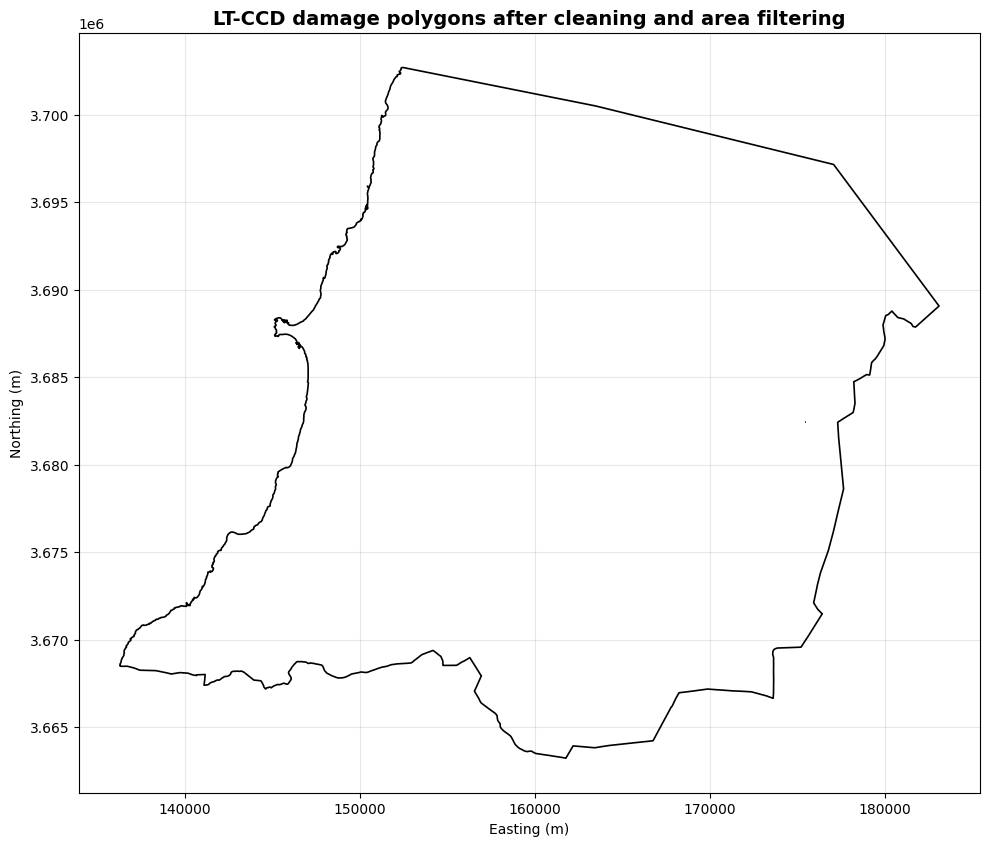

In [127]:
fig, ax = plt.subplots(figsize=(10, 10))

roi_gdf.boundary.plot(ax=ax, color="black", linewidth=1.2)

if "delta_gamma" in damage_gdf.columns:
    damage_gdf.plot(
        ax=ax,
        column="delta_gamma",
        cmap="Reds_r",
        legend=True,
        edgecolor="none"
    )
else:
    damage_gdf.plot(
        ax=ax,
        color="red",
        edgecolor="none"
    )

ax.set_title("LT-CCD damage polygons after cleaning and area filtering", fontsize=14, fontweight="bold")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [128]:
print("📍 Creating centroid coordinates for clustering...")

centroids = damage_gdf.geometry.centroid
damage_gdf["centroid_x"] = centroids.x
damage_gdf["centroid_y"] = centroids.y

coords = damage_gdf[["centroid_x", "centroid_y"]].to_numpy()

print(f"   ✅ Prepared centroid coordinates for {coords.shape[0]:,} polygons")

📍 Creating centroid coordinates for clustering...
   ✅ Prepared centroid coordinates for 1 polygons


In [129]:
print("🔍 Running DBSCAN clustering...")

db = DBSCAN(
    eps=dbscan_eps_m,
    min_samples=dbscan_min_samples
)

cluster_labels = db.fit_predict(coords)
damage_gdf["cluster_id"] = cluster_labels

n_noise = int(np.sum(cluster_labels == -1))
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)

print(f"   ✅ Clustering completed")
print(f"   Number of clusters: {n_clusters}")
print(f"   Noise polygons (isolated): {n_noise:,}")

🔍 Running DBSCAN clustering...
   ✅ Clustering completed
   Number of clusters: 0
   Noise polygons (isolated): 1


In [130]:
print("📊 Summarizing clusters...")

clustered_only = damage_gdf[damage_gdf["cluster_id"] != -1].copy()

if len(clustered_only) > 0:
    agg_dict = {
        "polygon_count": ("cluster_id", "size"),
        "total_area_m2": ("area_m2", "sum"),
        "mean_area_m2": ("area_m2", "mean"),
    }

    if "delta_gamma" in clustered_only.columns:
        agg_dict["mean_delta_gamma"] = ("delta_gamma", "mean")
    if "damage_class" in clustered_only.columns:
        agg_dict["dominant_damage_class"] = ("damage_class", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else None)

    cluster_summary = (
        clustered_only.groupby("cluster_id")
        .agg(**agg_dict)
        .reset_index()
        .sort_values(by="polygon_count", ascending=False)
    )
else:
    cluster_summary = pd.DataFrame(columns=[
        "cluster_id", "polygon_count", "total_area_m2", "mean_area_m2", "mean_delta_gamma", "dominant_damage_class"
    ])

display(cluster_summary.head(20))

📊 Summarizing clusters...


,cluster_id,polygon_count,total_area_m2,mean_area_m2,mean_delta_gamma,dominant_damage_class


In [131]:
print("🧽 Removing isolated polygons...")

if keep_only_clustered:
    filtered_gdf = damage_gdf[damage_gdf["cluster_id"] != -1].copy()
else:
    filtered_gdf = damage_gdf.copy()

removed_isolated = len(damage_gdf) - len(filtered_gdf)

print(f"   Removed isolated polygons: {removed_isolated:,}")
print(f"   Remaining clustered polygons: {len(filtered_gdf):,}")

🧽 Removing isolated polygons...
   Removed isolated polygons: 1
   Remaining clustered polygons: 0


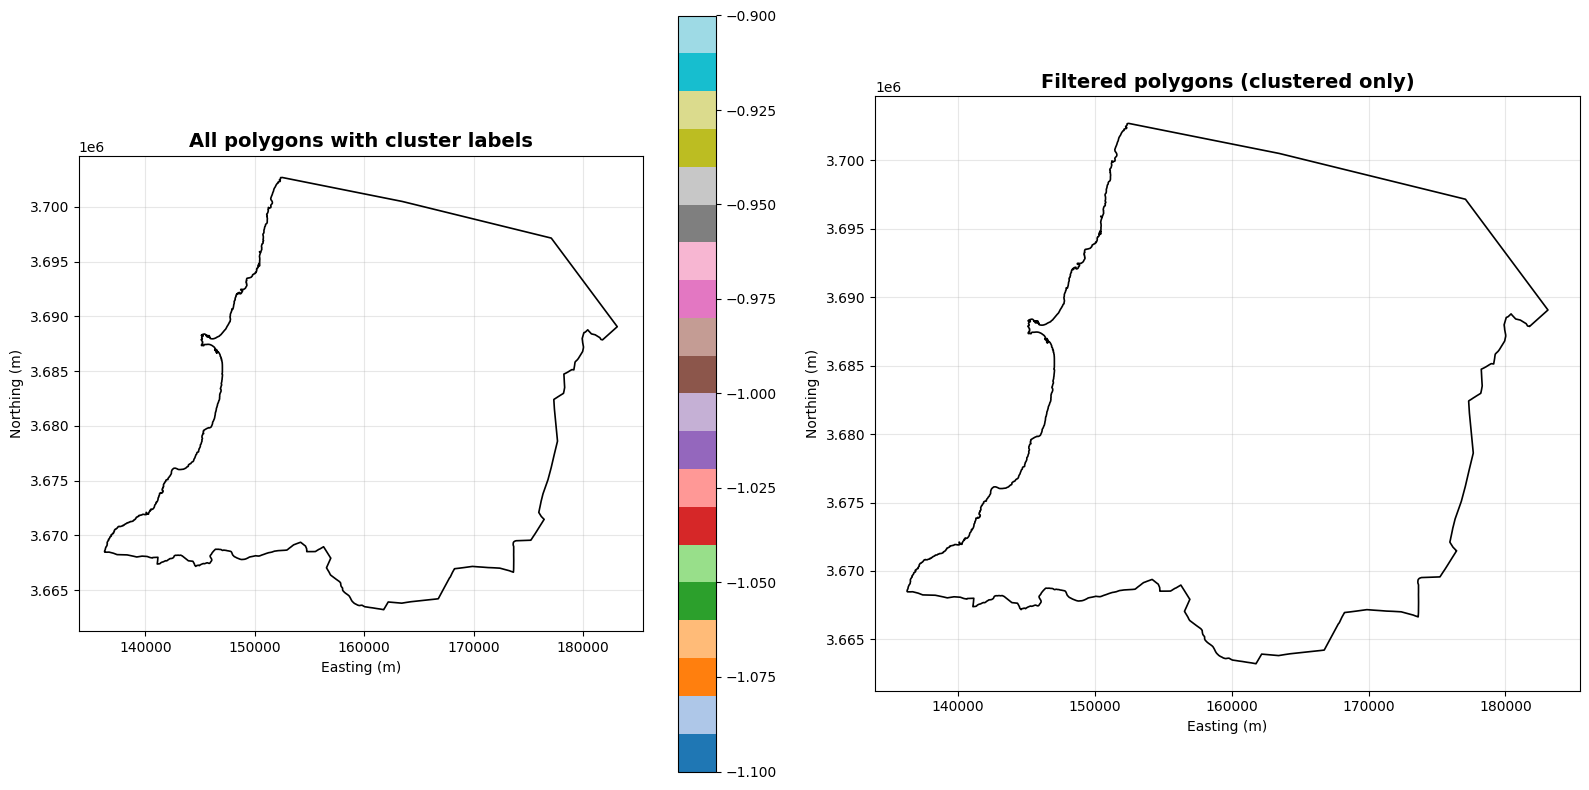

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Before filtering
roi_gdf.boundary.plot(ax=axes[0], color="black", linewidth=1.2)
damage_gdf.plot(
    ax=axes[0],
    column="cluster_id",
    cmap="tab20",
    legend=True,
    edgecolor="none"
)
axes[0].set_title("All polygons with cluster labels", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Easting (m)")
axes[0].set_ylabel("Northing (m)")
axes[0].grid(True, alpha=0.3)

# After filtering
roi_gdf.boundary.plot(ax=axes[1], color="black", linewidth=1.2)
filtered_gdf.plot(
    ax=axes[1],
    column="cluster_id",
    cmap="tab20",
    legend=True,
    edgecolor="none"
)
axes[1].set_title("Filtered polygons (clustered only)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Easting (m)")
axes[1].set_ylabel("Northing (m)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [133]:
print("🧩 Dissolving polygons by cluster...")

if len(filtered_gdf) > 0:
    cluster_dissolved = filtered_gdf.dissolve(by="cluster_id", as_index=False)

    # Recalculate dissolved cluster area
    cluster_dissolved["cluster_area_m2"] = cluster_dissolved.geometry.area

    # Merge cluster summary back
    if len(cluster_summary) > 0:
        merge_cols = ["cluster_id", "polygon_count", "total_area_m2"]
        if "mean_delta_gamma" in cluster_summary.columns:
            merge_cols.append("mean_delta_gamma")
        if "dominant_damage_class" in cluster_summary.columns:
            merge_cols.append("dominant_damage_class")

        cluster_dissolved = cluster_dissolved.merge(
            cluster_summary[merge_cols],
            on="cluster_id",
            how="left"
        )

    print(f"   ✅ Dissolved clusters created: {len(cluster_dissolved):,}")
else:
    cluster_dissolved = gpd.GeoDataFrame(columns=["cluster_id", "geometry"], crs=filtered_gdf.crs)
    print("   ℹ️ No clustered polygons available for dissolve")

🧩 Dissolving polygons by cluster...
   ℹ️ No clustered polygons available for dissolve


In [134]:
if len(cluster_dissolved) > 0:
    fig, ax = plt.subplots(figsize=(10, 10))

    roi_gdf.boundary.plot(ax=ax, color="black", linewidth=1.2)
    cluster_dissolved.plot(
        ax=ax,
        column="polygon_count",
        cmap="OrRd",
        legend=True,
        edgecolor="black",
        linewidth=0.4
    )

    ax.set_title("Dissolved LT-CCD damage clusters", fontsize=14, fontweight="bold")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No dissolved clusters to visualize.")

No dissolved clusters to visualize.


In [135]:
print("💾 Saving outputs...")

damage_gdf.to_file(clustered_polygons_path, driver="GeoJSON")
filtered_gdf.to_file(filtered_polygons_path, driver="GeoJSON")
cluster_summary.to_csv(cluster_summary_path, index=False)

if len(cluster_dissolved) > 0:
    cluster_dissolved.to_file(cluster_dissolved_path, driver="GeoJSON")

print(f"   ✅ Clustered polygons saved to: {clustered_polygons_path}")
print(f"   ✅ Filtered polygons saved to: {filtered_polygons_path}")
print(f"   ✅ Cluster summary saved to: {cluster_summary_path}")

if len(cluster_dissolved) > 0:
    print(f"   ✅ Dissolved clusters saved to: {cluster_dissolved_path}")

💾 Saving outputs...
   ✅ Clustered polygons saved to: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Results/Lebanon_South/SLC_1/LTCCD_Results_post02032026/cluster_filtering/ltccd_damage_polygons_with_cluster_id.geojson
   ✅ Filtered polygons saved to: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Results/Lebanon_South/SLC_1/LTCCD_Results_post02032026/cluster_filtering/ltccd_damage_polygons_cluster_filtered.geojson
   ✅ Cluster summary saved to: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Results/Lebanon_South/SLC_1/LTCCD_Results_post02032026/cluster_filtering/ltccd_cluster_summary.csv


In [136]:
print("📋 Final summary:")
print(f"   Input polygons after cleaning: {len(damage_gdf):,}")
print(f"   Filtered clustered polygons: {len(filtered_gdf):,}")
print(f"   Number of clusters: {len(cluster_summary):,}")
print(f"   Isolated polygons removed: {np.sum(damage_gdf['cluster_id'] == -1):,}")

if len(cluster_summary) > 0:
    print(f"   Largest cluster size: {cluster_summary['polygon_count'].max():,} polygons")
    print(f"   Largest cluster area: {cluster_summary['total_area_m2'].max()/1_000_000:.4f} km²")

print("✅ Cluster filtering completed successfully")

📋 Final summary:
   Input polygons after cleaning: 1
   Filtered clustered polygons: 0
   Number of clusters: 0
   Isolated polygons removed: 1
✅ Cluster filtering completed successfully
